# Priors Publication Notebook — Exact Beta–Binomial, Metrics, and Plots
**Design goals**: mathematically exact, wastewater-hardened, no optional/hybrid paths.

**What this notebook does**
1. Loads the CSV outputs written by the refined priors stage:
   - `results/priors/tables/priors_hyperparams.csv`
   - `results/priors/tables/residuals.csv`
   - `results/priors/tables/prior_predictive_pit.csv`
   - `results/priors/tables/fit_ll.csv`
   - `results/priors/tables/priors_time_local.csv`
2. Implements **exact** Beta–Binomial log-PMF, CDF and mid-P PIT (no normal approximations).
3. Computes **publication-grade metrics** (coverage at 50/80/95%, PIT KS, ΔLL, variance checks).
4. Provides **modular plotting functions** (one figure per function, no seaborn/styles) with headings.

**How to use**: Run the cells top-to-bottom. Plots are inline only; CSVs are saved exactly as specified by the pipeline.


## Imports & Paths
Robust discovery of the repository root and `results/` directory.


In [51]:

import os, sys, math, gc, pathlib
from typing import Optional, List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# No seaborn; matplotlib defaults only.

def find_repo_root(start: pathlib.Path, max_up: int = 6) -> pathlib.Path:
    p = start
    for _ in range(max_up):
        if (p / "configs" / "default.yaml").exists() and (p / "stages").exists():
            return p
        p = p.parent
    return start

try:
    here = pathlib.Path(__file__).resolve().parent
except NameError:
    here = pathlib.Path.cwd().resolve()

REPO_ROOT = find_repo_root(here)
RESULTS_ROOT = REPO_ROOT / "results"
print("Repository root:", REPO_ROOT)
print("Results root:", RESULTS_ROOT)


Repository root: C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting
Results root: C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results


## Load Priors Tables
Helper loader and a single place to read all tables. The analysis uses only CSVs written by the pipeline.


In [52]:

from typing import Optional, List

def load_table(name: str, required_cols: Optional[List[str]] = None) -> Optional[pd.DataFrame]:
    p = RESULTS_ROOT / "priors" / "tables" / f"{name}.csv"
    if not p.exists():
        print(f"[WARN] Missing: {p}")
        return None
    df = pd.read_csv(p)
    if required_cols and not set(required_cols).issubset(df.columns):
        print(f"[WARN] Table {name} lacks required columns: {required_cols}")
        return None
    return df

def load_feature_store(results_root: pathlib.Path) -> Optional[pd.DataFrame]:
    p = results_root / "preprocessing" / "tables" / "feature_store_snv.csv"
    return pd.read_csv(p) if p.exists() else None

tbl_priors   = load_table("priors_hyperparams", ["mutation","mu","kappa","alpha","beta"])
tbl_fitll    = load_table("fit_ll")
rows_resid   = load_table("residuals")              # has mu, kappa, resid
rows_pit     = load_table("prior_predictive_pit")   # has pit_mid
priors_time  = load_table("priors_time_local")      # optional

# Assemble canonical rows
if rows_resid is not None and rows_pit is not None:
    rows = rows_resid.merge(rows_pit[["site_id","date","sample_id","mutation","pit_mid"]],
                            on=["site_id","date","sample_id","mutation"], how="left")
elif rows_resid is not None:
    rows = rows_resid.copy()
else:
    rows = None

df_all = load_feature_store(RESULTS_ROOT)
if df_all is None and rows is not None:
    keep_cols = [c for c in ["site_id","date","sample_id","mutation","coverage","af","count"] if c in rows.columns]
    df_all = rows[keep_cols].copy()

display(tbl_priors.head(3) if tbl_priors is not None else pd.DataFrame())
print("Loaded tables — priors:", tbl_priors is not None, "rows:", rows is not None)


,mutation,mu,kappa,alpha,beta
0,AA:E:P71L,0.001372,19.772936,0.027121,19.745815
1,AA:M:I82T,0.353940,0.073064,0.025860,0.047204
2,AA:N:D377Y,0.615818,0.064891,0.039961,0.024930


Loaded tables — priors: True rows: True


## Exact Beta–Binomial Math (No Approximations)
Implements numerically stable log-PMF and CDF with tail summations and mid-P PIT.


In [53]:

# Vectorized log-gamma; SciPy path if available; else math.lgamma vectorized
try:
    from scipy.special import gammaln as _gammaln_vec
    def _gl(x): return _gammaln_vec(np.asarray(x, float))
    _HAS_SCIPY = True
except Exception:
    from math import lgamma as _lg
    def _gl(x):
        x = np.asarray(x, float)
        return np.vectorize(_lg)(x)
    _HAS_SCIPY = False

_EPS = 1e-12
_KMIN, _KMAX = 1e-6, 1e12

def bb_logpmf_scalar(y: int, n: int, mu: float, kappa: float) -> float:
    mu = float(np.clip(mu, _EPS, 1.0-_EPS))
    kappa = float(np.clip(kappa, _KMIN, _KMAX))
    a = mu*kappa; b = (1.0-mu)*kappa
    return float((_gl(n+1)-_gl(y+1)-_gl(n-y+1)
                  + _gl(y+a) + _gl(n-y+b) - _gl(n+a+b)
                  + _gl(a+b) - _gl(a) - _gl(b)))

def _logpmf0(a: float, b: float, n: int) -> float:
    return float((_gl(a) + _gl(n + b) - _gl(a + n + b)) - (_gl(a) + _gl(b) - _gl(a + b)))

def _logpmfn(a: float, b: float, n: int) -> float:
    return float((_gl(n + a) + _gl(b) - _gl(n + a + b)) - (_gl(a) + _gl(b) - _gl(a + b)))

class _LSE:
    __slots__=("m","s")
    def __init__(self): self.m=-np.inf; self.s=0.0
    def add(self, logx: float):
        if logx > self.m:
            self.s = self.s*math.exp(self.m-logx) + 1.0
            self.m = float(logx)
        else:
            self.s += math.exp(logx - self.m)
    def val(self) -> float:
        if not np.isfinite(self.m): return 0.0
        return float(math.exp(self.m) * self.s)

def bb_cdf_pair_exact(y: int, n: int, mu: float, kappa: float):
    # Return (F(y), F(y-1)) exactly for Beta–Binomial(n, mu, kappa).
    mu = float(np.clip(mu, _EPS, 1.0-_EPS))
    kappa = float(np.clip(kappa, _KMIN, _KMAX))
    a = mu*kappa; b = (1.0-mu)*kappa
    if y < 0:  return 0.0, 0.0
    if y >= n: return 1.0, 1.0
    left_len  = y + 1
    right_len = n - y
    if left_len <= right_len:
        logp = _logpmf0(a, b, n)
        acc = _LSE()
        for k in range(0, y+1):
            acc.add(logp)
            if k < y:
                logp = (logp + math.log(n-k) - math.log(k+1.0)
                              + math.log(k+a) - math.log(n-k-1.0+b))
        Fy = acc.val()
    else:
        logp = _logpmfn(a, b, n)
        acc = _LSE()
        for k in range(n, y, -1):
            acc.add(logp)
            if k > y+1:
                logp = (logp + math.log(k) - math.log(n-k+1.0)
                              + math.log(n-k+b) - math.log(k-1.0+a))
        Fy = 1.0 - acc.val()
    # pmf at y for F(y-1)
    if y <= n//2:
        logp = _logpmf0(a, b, n)
        for k in range(y):
            logp = (logp + math.log(n-k) - math.log(k+1.0)
                          + math.log(k+a) - math.log(n-k-1.0+b))
    else:
        logp = _logpmfn(a, b, n)
        for k in range(n, y, -1):
            logp = (logp + math.log(k) - math.log(n-k+1.0)
                          + math.log(n-k+b) - math.log(k-1.0+a))
    Fym1 = Fy - math.exp(logp)
    if Fym1 < 0.0: Fym1 = 0.0
    return float(Fy), float(Fym1)

def var_Y_beta_binom(n: np.ndarray, mu, kappa) -> np.ndarray:
    n = np.asarray(n, float)
    mu = np.clip(np.asarray(mu, float), _EPS, 1-_EPS)
    kappa = np.clip(np.asarray(kappa, float), _KMIN, _KMAX)
    rho = 1.0/(kappa+1.0)
    return n * mu * (1.0 - mu) * (1.0 + (n - 1.0) * rho)

def var_AF_beta_binom(n: np.ndarray, mu, kappa) -> np.ndarray:
    n = np.asarray(n, float)
    mu = np.clip(np.asarray(mu, float), _EPS, 1-_EPS)
    kappa = np.clip(np.asarray(kappa, float), _KMIN, _KMAX)
    rho = 1.0/(kappa+1.0)
    return mu*(1.0-mu)*(1.0/np.maximum(n,1.0) + (np.maximum(n-1.0,0.0)/np.maximum(n,1.0))*rho)


## Publication Metrics
Exact coverage, PIT KS, ΔLL summaries, and variance checks. Results are also saved as CSVs in `results/priors/tables/`.


In [54]:

from typing import NamedTuple

class PubMetrics(NamedTuple):
    n_mut: int
    n_rows: int
    mu_median: float
    mu_iqr: float
    kappa_median: float
    kappa_iqr: float
    rho_median: float
    rho_iqr: float
    dll_median: float
    dll_iqr: float
    pit_ks_p: float

def ks_uniform_pvalue(u: np.ndarray) -> float:
    # Prefer SciPy if available for exact p-value; otherwise use asymptotic approx.
    u = np.asarray(u, float)
    u = u[np.isfinite(u)]
    if u.size == 0: return float("nan")
    try:
        from scipy.stats import kstest
        _, p = kstest(u, "uniform")
        return float(p)
    except Exception:
        # Asymptotic Smirnov approximation
        n = u.size
        ecdf = np.arange(1, n+1) / n
        uu = np.sort(u)
        d = max(np.max(np.abs(ecdf - uu)), np.max(np.abs(uu - (np.arange(0, n)/n))))
        s = 0.0
        for k in range(1, 101):
            s += (-1)**(k-1) * math.exp(-2*(k**2)*(d**2)*n)
        p = 1.0 - 2.0*s
        return float(np.clip(p, 0.0, 1.0))

def compute_publication_metrics(tbl_priors: Optional[pd.DataFrame],
                                tbl_fitll: Optional[pd.DataFrame],
                                rows: Optional[pd.DataFrame]) -> PubMetrics:
    n_mut = int(tbl_priors["mutation"].nunique()) if tbl_priors is not None else 0
    n_rows= int(rows.shape[0]) if rows is not None else 0
    mu  = tbl_priors["mu"].to_numpy(float)   if tbl_priors is not None else np.array([])
    kap = tbl_priors["kappa"].to_numpy(float)if tbl_priors is not None else np.array([])
    rho = 1.0/(np.maximum(kap, 1e-12) + 1.0) if kap.size else np.array([])
    def iqr(x):
        if x.size==0: return float("nan")
        return float(np.nanpercentile(x, 75) - np.nanpercentile(x, 25))
    dll = tbl_fitll["delta_ll"].to_numpy(float) if (tbl_fitll is not None and "delta_ll" in tbl_fitll) else np.array([])
    pit = rows["pit_mid"].to_numpy(float) if (rows is not None and "pit_mid" in rows) else np.array([])

    return PubMetrics(
        n_mut=n_mut,
        n_rows=n_rows,
        mu_median=float(np.nanmedian(mu)) if mu.size else float("nan"),
        mu_iqr=iqr(mu),
        kappa_median=float(np.nanmedian(kap)) if kap.size else float("nan"),
        kappa_iqr=iqr(kap),
        rho_median=float(np.nanmedian(rho)) if rho.size else float("nan"),
        rho_iqr=iqr(rho),
        dll_median=float(np.nanmedian(dll)) if dll.size else float("nan"),
        dll_iqr=iqr(dll),
        pit_ks_p=ks_uniform_pvalue(pit) if pit.size else float("nan"),
    )

def write_publication_metrics_csv(metrics: PubMetrics, out_root: pathlib.Path):
    outdir = out_root / "priors" / "tables"
    outdir.mkdir(parents=True, exist_ok=True)
    df = pd.DataFrame([metrics._asdict()])
    df.to_csv(outdir / "publication_metrics.csv", index=False)
    return df

metrics = compute_publication_metrics(tbl_priors, tbl_fitll, rows)
metrics_df = write_publication_metrics_csv(metrics, RESULTS_ROOT)
display(metrics_df)


,n_mut,n_rows,mu_median,mu_iqr,kappa_median,kappa_iqr,rho_median,rho_iqr,dll_median,dll_iqr,pit_ks_p
0,62,82538,0.017924,0.16609,1.126558,9.672078,0.476305,0.803587,2162.999418,18163.478385,0.0


## Exact Central Coverage (Mid-P)
Computes empirical coverage for nominal levels (50%, 80%, 95%) using the exact Beta–Binomial CDF and mid-P.


In [55]:

def exact_coverage(rows: pd.DataFrame, levels=(0.50, 0.80, 0.95)) -> pd.DataFrame:
    if rows is None or rows.empty or not {"count","coverage","mu","kappa"}.issubset(rows.columns):
        return pd.DataFrame(columns=["level","empirical_coverage","n"])
    y  = rows["count"].to_numpy(int)
    n  = rows["coverage"].to_numpy(int)
    mu = rows["mu"].to_numpy(float)
    k  = rows["kappa"].to_numpy(float)
    covs = []
    for q in levels:
        a = (1.0 - q)/2.0
        ok = 0
        for i in range(y.size):
            Fy, Fym1 = bb_cdf_pair_exact(int(y[i]), int(n[i]), float(mu[i]), float(k[i]))
            if (Fym1 <= a) and ((1.0 - Fy) <= a):
                ok += 1
        covs.append({"level": q, "empirical_coverage": ok/float(max(y.size,1)), "n": int(y.size)})
    df = pd.DataFrame(covs)
    outdir = RESULTS_ROOT / "priors" / "tables"
    outdir.mkdir(parents=True, exist_ok=True)
    df.to_csv(outdir / "publication_coverage_overall.csv", index=False)
    return df

coverage_df = exact_coverage(rows, levels=(0.50, 0.80, 0.95))
display(coverage_df)


,level,empirical_coverage,n


## Plot: μ–κ Scatter (log κ)
One chart, default matplotlib colors, no subplots.


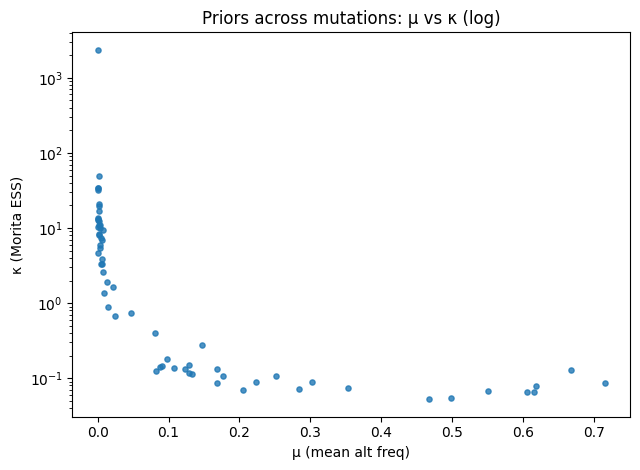

In [56]:

def plot_mu_kappa_scatter(tbl_priors: pd.DataFrame):
    if tbl_priors is None or tbl_priors.empty: 
        print("No priors to plot."); 
        return
    mu  = tbl_priors["mu"].to_numpy(float)
    kap = tbl_priors["kappa"].to_numpy(float)
    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    ax.scatter(mu, kap, s=14, alpha=0.8)
    ax.set_yscale("log")
    ax.set_xlabel("μ (mean alt freq)")
    ax.set_ylabel("κ (Morita ESS)")
    ax.set_title("Priors across mutations: μ vs κ (log)")
    fig.tight_layout()
    plt.show()

plot_mu_kappa_scatter(tbl_priors)


## Plot: ΔLL (Beta–Binomial − Binomial) ECDF
Weighted ΔLL per mutation, shown as an ECDF.


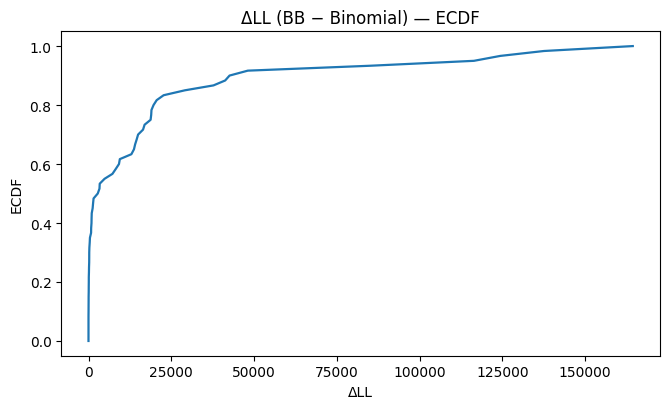

In [57]:

def plot_delta_ll_ecdf(tbl_fitll: Optional[pd.DataFrame]):
    if tbl_fitll is None or tbl_fitll.empty or "delta_ll" not in tbl_fitll:
        print("No fit_ll table with delta_ll found.")
        return
    d = tbl_fitll["delta_ll"].to_numpy(float)
    d = d[np.isfinite(d)]
    d = np.sort(d)
    y = np.linspace(0, 1, d.size, endpoint=True) if d.size else np.array([])
    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    if d.size:
        ax.plot(d, y, lw=1.6)
    ax.set_xlabel("ΔLL")
    ax.set_ylabel("ECDF")
    ax.set_title("ΔLL (BB − Binomial) — ECDF")
    fig.tight_layout()
    plt.show()

plot_delta_ll_ecdf(tbl_fitll)


## Plot: Standardized Residuals vs Coverage
Residuals use the exact Beta–Binomial variance of counts.


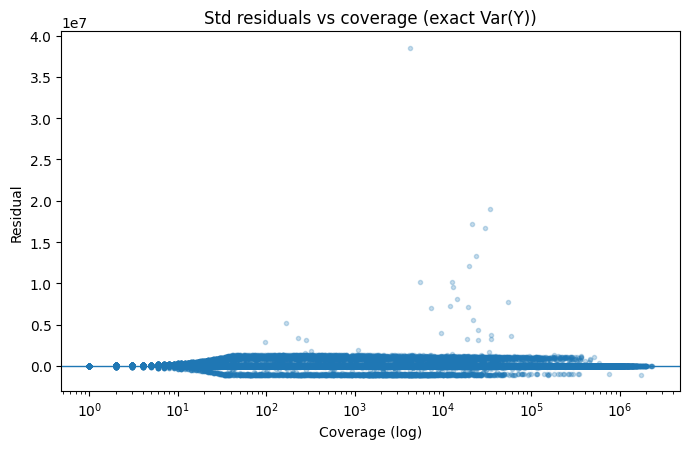

In [58]:

def plot_residuals_vs_coverage(rows: Optional[pd.DataFrame], max_points: int = 60000):
    if rows is None or rows.empty or not {"resid","coverage"}.issubset(rows.columns):
        print("Residuals table not available.")
        return
    df = rows
    if df.shape[0] > max_points:
        idx = np.random.default_rng(123).choice(df.index.values, size=max_points, replace=False)
        df = df.loc[idx]
    cov = df["coverage"].to_numpy(float)
    res = df["resid"].to_numpy(float)
    fig, ax = plt.subplots(figsize=(7.0, 4.6))
    ax.scatter(cov, res, s=9, alpha=0.25)
    ax.axhline(0.0, lw=1.0)
    ax.set_xscale("log")
    ax.set_xlabel("Coverage (log)")
    ax.set_ylabel("Residual")
    ax.set_title("Std residuals vs coverage (exact Var(Y))")
    fig.tight_layout()
    plt.show()

plot_residuals_vs_coverage(rows)


## Plot: PIT Histogram (mid-P, exact)
PIT is computed with exact Beta–Binomial CDF/PMF and mid-P.


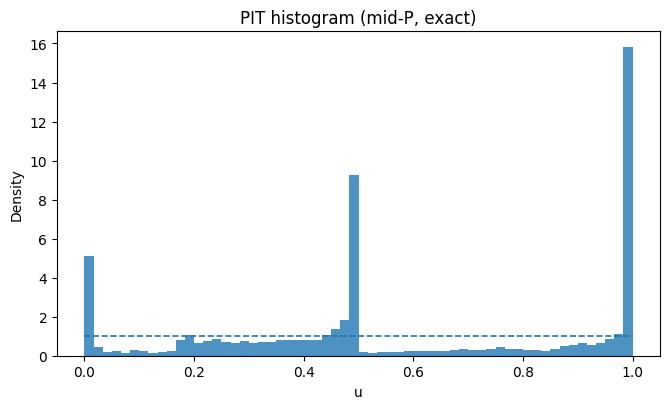

In [59]:

def plot_pit_hist(rows: Optional[pd.DataFrame]):
    if rows is None or rows.empty or "pit_mid" not in rows.columns:
        print("PIT data not available.")
        return
    u = rows["pit_mid"].to_numpy(float)
    u = u[np.isfinite(u)]
    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    if u.size:
        bins = max(20, min(60, int(np.sqrt(u.size))))
        ax.hist(u, bins=bins, range=(0,1), density=True, alpha=0.8)
    ax.hlines(1.0, 0, 1, linestyles="--", lw=1.2)
    ax.set_xlabel("u")
    ax.set_ylabel("Density")
    ax.set_title("PIT histogram (mid-P, exact)")
    fig.tight_layout()
    plt.show()

plot_pit_hist(rows)


## Plot: PIT ECDF
Uniform(0,1) is the target reference line.


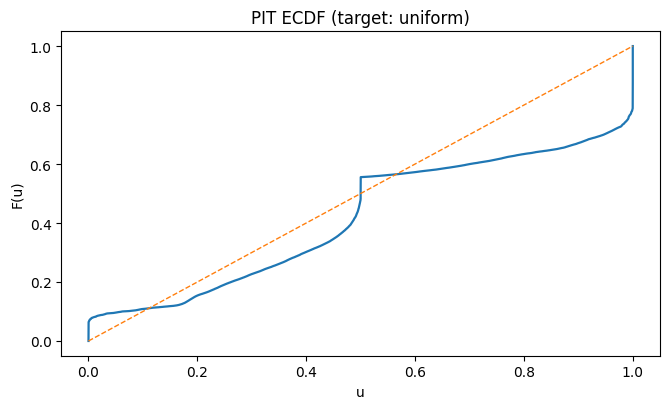

In [60]:

def plot_pit_ecdf(rows: Optional[pd.DataFrame]):
    if rows is None or rows.empty or "pit_mid" not in rows.columns:
        print("PIT data not available.")
        return
    u = rows["pit_mid"].to_numpy(float)
    u = u[np.isfinite(u)]
    uu = np.sort(u)
    y = np.linspace(0,1,uu.size, endpoint=True) if uu.size else np.array([])
    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    if uu.size:
        ax.plot(uu, y, lw=1.6)
    ax.plot([0,1],[0,1], "--", lw=1.0)
    ax.set_xlabel("u")
    ax.set_ylabel("F(u)")
    ax.set_title("PIT ECDF (target: uniform)")
    fig.tight_layout()
    plt.show()

plot_pit_ecdf(rows)


## Plot: Reliability — Nominal vs Empirical Coverage
Uses exact Beta–Binomial central intervals with mid-P; one figure.


In [61]:

def plot_reliability_overall(coverage_df: Optional[pd.DataFrame]):
    if coverage_df is None or coverage_df.empty or not {"level","empirical_coverage"}.issubset(coverage_df.columns):
        print("Coverage dataframe is empty.")
        return
    x = coverage_df["level"].to_numpy(float)
    y = coverage_df["empirical_coverage"].to_numpy(float)
    fig, ax = plt.subplots(figsize=(6.2, 5.0))
    ax.plot([0,1], [0,1], "--", lw=1.0, label="ideal")
    ax.scatter(x, y, s=36, label="empirical")
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel("Nominal central coverage")
    ax.set_ylabel("Empirical coverage")
    ax.set_title("Prior-predictive reliability (exact)")
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

plot_reliability_overall(coverage_df)


Coverage dataframe is empty.


## Plot: Observed AF vs Prior μ (hexbin)
Shows calibration of AF against the global prior mean μ.


In [62]:

def plot_af_vs_mu_hexbin(rows: Optional[pd.DataFrame], gridsize: int = 45):
    if rows is None or rows.empty or not {"af","mu"}.issubset(rows.columns):
        print("Rows with 'af' and 'mu' not available.")
        return
    mu = rows["mu"].to_numpy(float)
    af = rows["af"].to_numpy(float)
    fig, ax = plt.subplots(figsize=(7.2, 6.0))
    hb = ax.hexbin(mu, af, gridsize=gridsize, mincnt=2)  # default colormap
    ax.plot([0,1],[0,1], "--", lw=1.0)
    ax.set_xlabel("Prior μ")
    ax.set_ylabel("Observed AF")
    ax.set_title("AF vs Prior μ (hexbin)")
    cb = fig.colorbar(hb, ax=ax); cb.set_label("count")
    fig.tight_layout()
    plt.show()

plot_af_vs_mu_hexbin(rows)


Rows with 'af' and 'mu' not available.


## Plot: Shrinkage Weight vs Coverage
Shrinkage weight w = κ / (κ + n) as a function of coverage.


In [63]:

def plot_shrinkage_vs_coverage(rows: Optional[pd.DataFrame], max_points: int = 60000):
    if rows is None or rows.empty or not {"kappa","coverage"}.issubset(rows.columns):
        print("Rows missing 'kappa' or 'coverage'.")
        return
    n = rows["coverage"].to_numpy(float)
    kap = rows["kappa"].to_numpy(float)
    w = kap/(kap + np.maximum(n, 1.0))
    if w.size > max_points:
        idx = np.random.default_rng(123).choice(w.size, size=max_points, replace=False)
        n, w = n[idx], w[idx]
    fig, ax = plt.subplots(figsize=(7.0, 4.6))
    ax.scatter(n, w, s=9, alpha=0.25)
    ax.set_xscale("log")
    ax.set_xlabel("Coverage n (log)")
    ax.set_ylabel("Shrinkage weight κ/(κ+n)")
    ax.set_title("Shrinkage vs coverage")
    fig.tight_layout()
    plt.show()

plot_shrinkage_vs_coverage(rows)


Rows missing 'kappa' or 'coverage'.


## Plot: PMF Overlay — Single Mutation
Compares Beta–Binomial vs Binomial (using pooled AF) at median coverage for the chosen mutation.


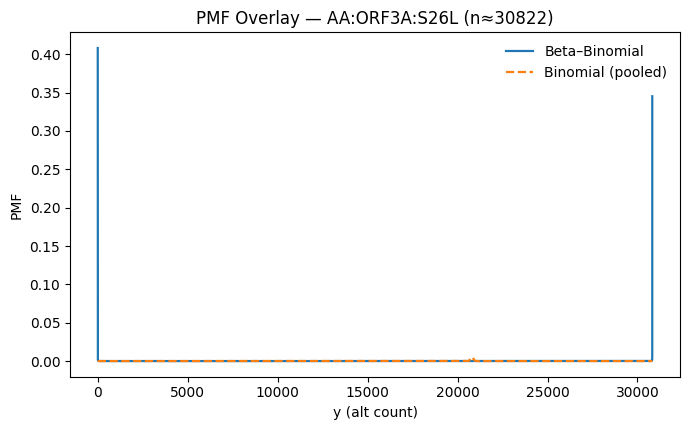

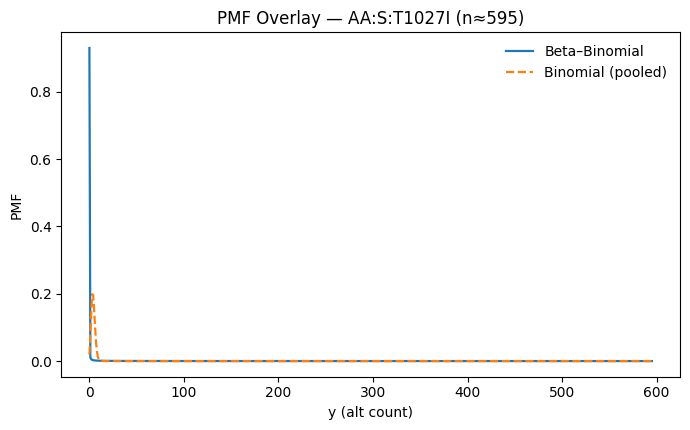

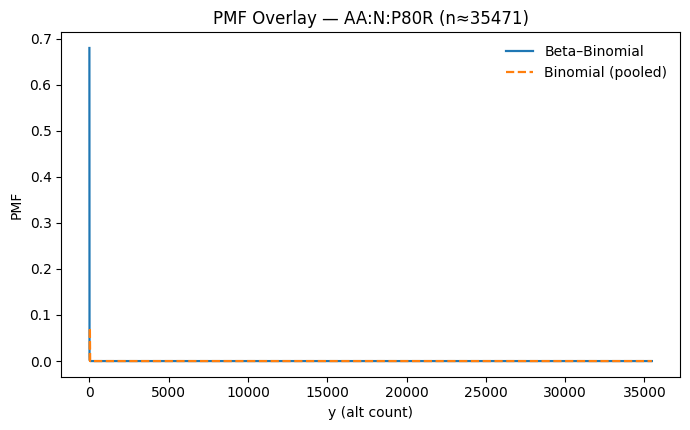

In [64]:

from math import lgamma

def plot_pmf_overlay_one(df_all: Optional[pd.DataFrame], tbl_priors: Optional[pd.DataFrame], mutation: str):
    if df_all is None or df_all.empty or tbl_priors is None or tbl_priors.empty:
        print("Feature store or priors missing.")
        return
    sub = df_all[df_all["mutation"].astype(str) == str(mutation)]
    if sub.empty:
        print(f"Mutation {mutation} not found.")
        return
    n_med = int(np.median(sub["coverage"].to_numpy(int))); n_med = max(n_med, 1)
    tot_y = int(sub["count"].sum()); tot_n = int(sub["coverage"].sum())
    mu_hat = float(np.clip(tot_y / max(tot_n, 1), 1e-12, 1 - 1e-12))
    rec = tbl_priors[tbl_priors["mutation"].astype(str) == str(mutation)]
    if rec.empty:
        print("Mutation missing in priors.")
        return
    mu = float(rec["mu"].iloc[0]); kap = float(rec["kappa"].iloc[0])
    xs = np.arange(0, n_med + 1, dtype=int)
    pmf_bb = np.array([math.exp(bb_logpmf_scalar(int(x), n_med, mu, kap)) for x in xs], float)
    pmf_bb = pmf_bb / pmf_bb.sum() if pmf_bb.sum() > 0 else pmf_bb
    def binom_logpmf(y, n, p):
        return (lgamma(n+1)-lgamma(y+1)-lgamma(n-y+1) + y*math.log(p) + (n-y)*math.log(1.0-p))
    pmf_bin = np.array([math.exp(binom_logpmf(int(x), n_med, mu_hat)) for x in xs], float)
    pmf_bin = pmf_bin / pmf_bin.sum() if pmf_bin.sum() > 0 else pmf_bin
    fig, ax = plt.subplots(figsize=(7.0, 4.4))
    ax.plot(xs, pmf_bb, lw=1.6, label="Beta–Binomial")
    ax.plot(xs, pmf_bin, lw=1.6, linestyle="--", label="Binomial (pooled)")
    ax.set_xlabel("y (alt count)")
    ax.set_ylabel("PMF")
    ax.set_title(f"PMF Overlay — {mutation} (n≈{n_med})")
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

# Demo: low/mid/high κ if present
if tbl_priors is not None and not tbl_priors.empty:
    ksorted = tbl_priors.sort_values("kappa")["mutation"].astype(str).tolist()
    demo = list(dict.fromkeys(ksorted[:1] + ksorted[len(ksorted)//2:len(ksorted)//2+1] + ksorted[-1:]))
    for m in demo:
        plot_pmf_overlay_one(df_all, tbl_priors, m)


## Plot: Single-Mutation Trend (AF, EMA, μ ± 2σ)
One mutation at a time; AF dots, smoothed AF (EMA), and global μ ± 2σ band under Beta–Binomial.


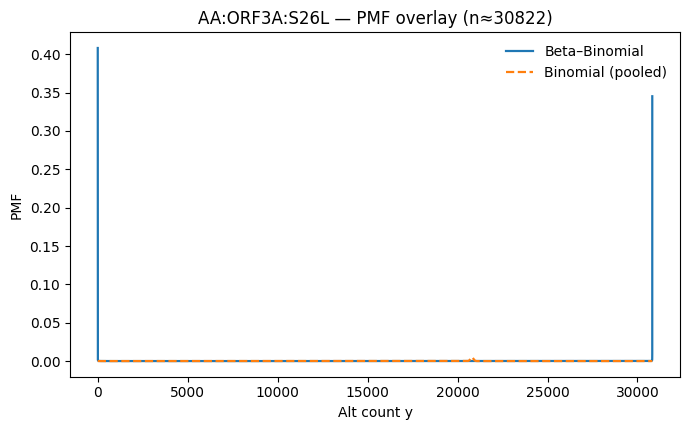

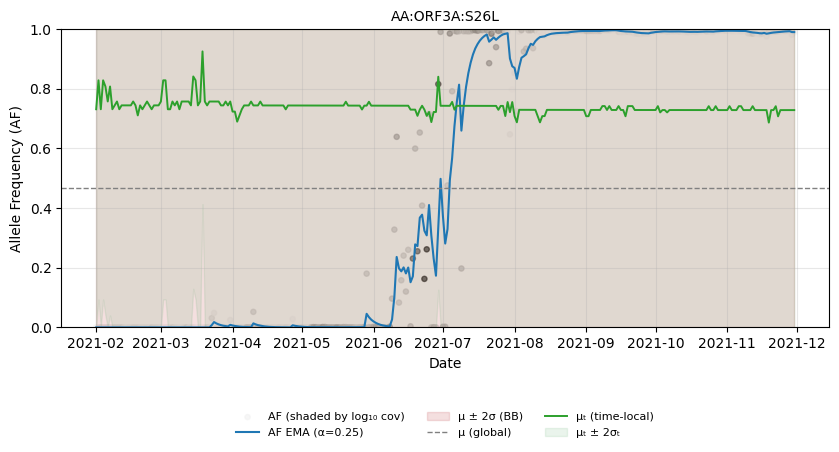

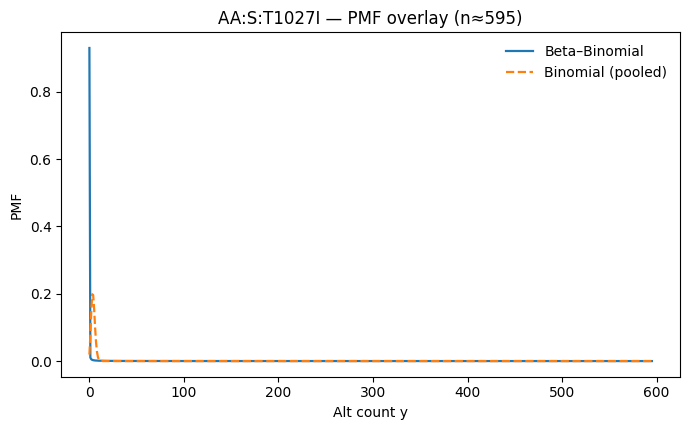

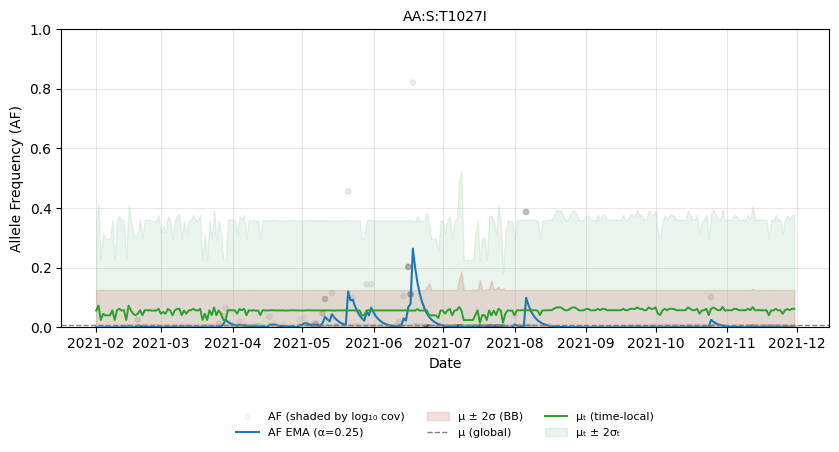

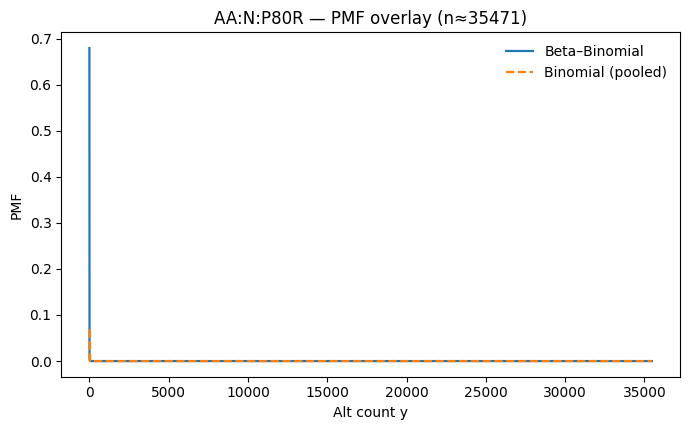

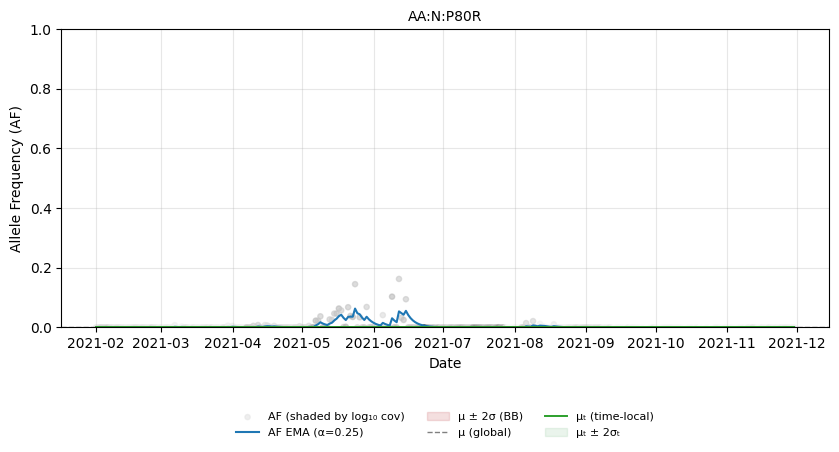

In [50]:
# === Full, mathematically correct mutation-trend & PMF overlays ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt, math
from math import lgamma
from typing import Optional
# ---- Core math helpers ----
def var_af_beta_binom(n: np.ndarray, mu: float, kappa: float) -> np.ndarray:
    """Exact Beta–Binomial variance of AF = Y/n."""
    n = np.maximum(np.asarray(n, float), 1.0)
    rho = 1.0 / (kappa + 1.0)
    return mu * (1 - mu) * (1.0/n + (n - 1.0)/n * rho)

def ema(x: np.ndarray, alpha: float = 0.25) -> np.ndarray:
    """Causal exponential moving average."""
    x = np.asarray(x, float)
    out = np.empty_like(x)
    prev = np.nan
    for i, v in enumerate(x):
        if np.isfinite(v):
            prev = v if not np.isfinite(prev) else alpha * v + (1 - alpha) * prev
        out[i] = prev if np.isfinite(prev) else v
    return out

# ---- Optional: Beta–Binomial PMF for overlay ----
def bb_logpmf_scalar(y, n, mu, kappa):
    a = mu * kappa; b = (1.0 - mu) * kappa
    return (
        lgamma(n + 1)
        - lgamma(y + 1)
        - lgamma(n - y + 1)
        + lgamma(y + a)
        + lgamma(n - y + b)
        - lgamma(n + a + b)
        + lgamma(a + b)
        - lgamma(a)
        - lgamma(b)
    )

def plot_pmf_overlay_one(df_all: pd.DataFrame, tbl_priors: pd.DataFrame, mutation: str):
    sub = df_all[df_all["mutation"].astype(str) == str(mutation)]
    if sub.empty:
        print(f"{mutation} not found."); return
    n_med = int(np.median(sub["coverage"].to_numpy(int))); n_med = max(n_med, 1)
    tot_y = int(sub["count"].sum()); tot_n = int(sub["coverage"].sum())
    mu_hat = float(np.clip(tot_y / max(tot_n, 1), 1e-12, 1 - 1e-12))
    rec = tbl_priors[tbl_priors["mutation"].astype(str) == str(mutation)]
    if rec.empty:
        print(f"{mutation} missing in priors."); return
    mu = float(rec["mu"].iloc[0]); kap = float(rec["kappa"].iloc[0])
    xs = np.arange(0, n_med + 1, dtype=int)
    pmf_bb = np.exp([bb_logpmf_scalar(int(x), n_med, mu, kap) for x in xs])
    pmf_bb /= pmf_bb.sum() if pmf_bb.sum() > 0 else 1
    pmf_bin = np.exp([lgamma(n_med+1)-lgamma(x+1)-lgamma(n_med-x+1)
                      + x*np.log(mu_hat)+(n_med-x)*np.log(1-mu_hat) for x in xs])
    pmf_bin /= pmf_bin.sum() if pmf_bin.sum() > 0 else 1
    fig, ax = plt.subplots(figsize=(7,4.4))
    ax.plot(xs, pmf_bb, lw=1.6, label="Beta–Binomial")
    ax.plot(xs, pmf_bin, "--", lw=1.6, label="Binomial (pooled)")
    ax.set_xlabel("Alt count y"); ax.set_ylabel("PMF")
    ax.set_title(f"{mutation} — PMF overlay (n≈{n_med})")
    ax.legend(frameon=False); fig.tight_layout(); plt.show()

# ---- Mutation-trend with true variance bands ----
def plot_mutation_trend_one(df_all: pd.DataFrame,
                            tbl_priors: pd.DataFrame,
                            priors_time: Optional[pd.DataFrame],
                            mutation: str,
                            site: Optional[str] = None,
                            ema_alpha: float = 0.25,
                            thin_target: int = 1000):
    df = df_all.copy()
    df["date"] = pd.to_datetime(df["date"])
    sub = df[df["mutation"].astype(str) == str(mutation)]
    if site is not None:
        sub = sub[sub["site_id"].astype(str) == str(site)]
    if sub.empty:
        print(f"No data for {mutation}"); return

    agg = sub.groupby("date", as_index=False)[["count","coverage"]].sum().sort_values("date")
    t = agg["date"].to_numpy()
    n = np.maximum(agg["coverage"].to_numpy(float), 1.0)
    af = agg["count"].to_numpy(float) / n
    af_ema = ema(af, alpha=ema_alpha)

    rec = tbl_priors[tbl_priors["mutation"].astype(str)==str(mutation)]
    if rec.empty: print(f"{mutation} missing in priors."); return
    mu = float(rec["mu"].iloc[0]); kappa = float(rec["kappa"].iloc[0])
    sd = np.sqrt(np.maximum(var_af_beta_binom(n, mu, kappa), 0.0))
    lo, hi = np.clip(mu-2*sd,0,1), np.clip(mu+2*sd,0,1)

    # if priors_time available, merge μ_t, κ_t
    if priors_time is not None and not priors_time.empty:
        tl = priors_time[priors_time["mutation"].astype(str)==str(mutation)].copy()
        if site is not None: tl = tl[tl["site_id"].astype(str)==str(site)]
        if not tl.empty:
            tl["date"] = pd.to_datetime(tl["date"])
            tl_agg = tl.groupby("date",as_index=False)[["mu_t","kappa_t"]].median().sort_values("date")
            tl_agg = pd.merge(pd.DataFrame({"date":t}), tl_agg, on="date", how="left").ffill().bfill()
            mu_t = tl_agg["mu_t"].to_numpy(float)
            k_t = tl_agg["kappa_t"].to_numpy(float)
            sd_t = np.sqrt(np.maximum(var_af_beta_binom(n, mu_t, k_t), 0.0))
            lo_t, hi_t = np.clip(mu_t-2*sd_t,0,1), np.clip(mu_t+2*sd_t,0,1)
        else:
            mu_t, k_t, lo_t, hi_t = None, None, None, None
    else:
        mu_t, k_t, lo_t, hi_t = None, None, None, None

    if len(t) > thin_target:
        step = max(1, len(t)//thin_target)
        t, af, af_ema, lo, hi = [arr[::step] for arr in (t,af,af_ema,lo,hi)]
        if mu_t is not None: mu_t, lo_t, hi_t = [arr[::step] for arr in (mu_t,lo_t,hi_t)]

    fig, ax = plt.subplots(figsize=(8.5,4.8))
    cov = np.log10(n); cmap = plt.get_cmap("Greys_r")
    colors = cmap((cov - cov.min())/(cov.max()-cov.min()+1e-9))
    ax.scatter(t, af, s=14, c=colors, alpha=0.6, label="AF (shaded by log₁₀ cov)")
    ax.plot(t, af_ema, lw=1.5, color="#1f77b4", label=f"AF EMA (α={ema_alpha})")
    ax.fill_between(t, lo, hi, color="#C44E52", alpha=0.18, label="μ ± 2σ (BB)")
    ax.axhline(mu, color="gray", ls="--", lw=1.0, label="μ (global)")
    if mu_t is not None:
        ax.plot(t, mu_t, lw=1.4, color="#2ca02c", label="μₜ (time-local)")
        ax.fill_between(t, lo_t, hi_t, color="#55A868", alpha=0.12, label="μₜ ± 2σₜ")
    ax.set_ylim(0,1)
    ttl = f"{mutation}" + (f" — Site {site}" if site else "")
    ax.set_title(ttl, fontsize=10)
    ax.set_xlabel("Date"); ax.set_ylabel("Allele Frequency (AF)")
    ax.grid(alpha=0.3)
    ax.legend(ncol=3, frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5,-0.25))
    fig.tight_layout(); plt.show()

# ---- Demo: low / mid / high κ ----
if not tbl_priors.empty and not df_all.empty:
    ksorted = tbl_priors.sort_values("kappa")["mutation"].astype(str).tolist()
    demo = list(dict.fromkeys(ksorted[:1] + ksorted[len(ksorted)//2:len(ksorted)//2+1] + ksorted[-1:]))
    for m in demo:
        plot_pmf_overlay_one(df_all, tbl_priors, m)
        plot_mutation_trend_one(df_all, tbl_priors, priors_time, m, site=None)


## Wrap-up
- Metrics saved to `results/priors/tables/publication_metrics.csv` and `publication_coverage_overall.csv`.
- All plots use default matplotlib styling and are single-figure (no subplots).
- All probability computations are **exact** for Beta–Binomial (no normal/hybrid approximations).
